# Applied ML Workshop — Pneumonia Detection

**Duration:** ~1.5 hours  

1. The data used are from the [Chest X-Ray Pneumonia dataset](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia).


---
## Block 1 — ML workflow & problem framing

*Discussion: read this section before running code.*

**Machine learning** is the process of learning patterns from data so a system can perform tasks on new, unseen inputs — such as predicting a value, classifying an observation, or revealing hidden structure.

| Type                       | Analogy                               | What the model learns                             |
| -------------------------- | ------------------------------------- | ------------------------------------------------- |
| **Supervised learning**    | Fruit with labels ("apple", "banana") | Map inputs to known outputs from labeled examples |
| **Unsupervised learning**  | Unlabeled mixed fruit                 | Group similar items without predefined categories |
| **Reinforcement learning** | Puppy rewarded for fetching apples    | Optimal actions through trial, error, and rewards |


The ML workflow below shows how these steps apply in practice.

| Step | What you do | Example (pneumonia workshop) |
|------|-------------|------------------------------|
| 1. **Define problem** | State the real-world goal and a measurable proxy metric | Goal: detect pneumonia; metric: recall on pneumonia class |
| 2. **Prepare data** | Load, clean, explore, split, preprocess | Load X-rays; normalize pixels; train/val/test split |
| 3. **Choose model** | Match architecture to data type; start simple | CNN for images; linear regression for tabular baseline |
| 4. **Train** | Minimize loss by updating model weights | Forward → loss → backward → optimizer step |
| 5. **Validate** | Monitor performance on held-out validation data | Track val accuracy each epoch; tune learning rate |
| 6. **Test & report** | Evaluate once on test set; report metrics and failures | Confusion matrix; inspect misclassified X-rays |
| 7. **Iterate** | Loop back if performance or requirements change | Add augmentation, change architecture, collect more data |


```mermaid
flowchart LR
    A[Define problem] --> B[Prepare data]
    B --> C[Choose model]
    C --> D[Train]
    D --> E[Validate]
    E --> F{Good enough?}
    F -->|No| C
    F -->|No| B
    F -->|Yes| G[Test and report]
    G --> H[Deploy or publish]
    H -->|New data| B
```

**Critical rule:** the **test set** is touched only once, at the end. Validation guides tuning; testing estimates real-world performance.

> **Checkpoint:** For your project, what would be a real-world goal and a proxy metric? What might be the constraints?



### Essential concepts

- **Supervised learning** — learn from labeled examples (`PNEUMONIA` / `NORMAL` folders).
- **Model** — parameterized function (CNN weights).
- **Loss** — scalar to minimize; wrong predictions increase loss.
- **Optimizer** — updates weights using gradients from the loss.
- **Epoch** — one full pass through the training set.
- **Train / val / test** — train to learn; val to monitor and tune; test to estimate real-world performance.




---
## Block 2 — Load & explore data

Set paths and load the chest X-ray dataset. Inspect class balance and sample images.


In [ ]:
# --- Configuration ---
# Path to dataset root (must contain train/, val/, test/ subfolders)
DATA_ROOT = '/ocean/projects/tra210016p/jjohn2/chest_xray'
LABELS = ['PNEUMONIA', 'NORMAL']

# Workshop demo: limit images per class for demo (set None for full dataset)
MAX_SAMPLES_PER_CLASS = 300

# hyperparameters
random_seed = 2020
NUM_EPOCHS = 6
BATCH_SIZE = 32
IMG_SIZE = 150


In [11]:
import os
import time
from itertools import product
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder


### Dataset Exploration

The dataset contains 5,863 pediatric chest X-rays images (JPEG) in `train/`, `val/`, and `test/` folders, each with `PNEUMONIA` and `NORMAL` subfolders. Images were quality-controlled and labeled by expert physicians before being released for ML training.


In [ ]:
SPLITS = ('train', 'val', 'test')

'''
Helper functions to explore the dataset class distribution.
'''
def build_image_catalog(data_root, splits=SPLITS, labels=LABELS):
    rows = [
        {'split': split, 'label': label, 'path': str(path)}
        for split, label in product(splits, labels)
        for path in sorted((Path(data_root) / split / label).iterdir())
        if path.is_file()
    ]
    return pd.DataFrame(rows)


catalog = build_image_catalog(DATA_ROOT)

split_counts = catalog.groupby(['split', 'label']).size().unstack(fill_value=0)
print('Images per split and class:')
print(split_counts)
totals = split_counts.sum(axis=1)
print(f"\nTrain: {totals['train']}  Val: {totals['val']}  Test: {totals['test']}")


Images per split and class:
label  NORMAL  PNEUMONIA
split                   
test      234        390
train    1341       3875
val         8          8

Train: 5216  Val: 16  Test: 624


> **Checkpoint:** How does the dataset distribution look like? How might it impact the model performance if we use the data as-is?

In [ ]:
'''
Helper functions to explore the dataset image sizes
'''
size_sample = (
    catalog.query('split == "train"')
    .sort_values('path')
    .groupby('label', group_keys=False)
    .head(100)
)

def probe_size(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return pd.Series({'height': pd.NA, 'width': pd.NA})
    return pd.Series({'height': img.shape[0], 'width': img.shape[1]})
    
size_sample = size_sample.join(size_sample['path'].apply(probe_size))

sizes = size_sample.dropna(subset=['height', 'width'])
if not sizes.empty:
    common_sizes = (
        sizes.groupby(['height', 'width'])
        .size()
        .sort_values(ascending=False)
        .head(5)
    )
    print('\nMost common image sizes in train sample (height x width):')
    print(common_sizes.rename('count').to_string())
    print(
        f'\nTrain sample — height: {sizes.height.min():.0f}–{sizes.height.max():.0f}, '
        f'width: {sizes.width.min():.0f}–{sizes.width.max():.0f}'
    )


Most common image sizes in train sample (height x width):
height  width
664     1016     2
307     502      1
1287    1766     1
1228    1608     1
1237    1156     1

Train sample — height: 307–2025, width: 502–2396


> **Checkpoint:** We need to feed the images of same sizes to the model. How to decide the image size to use and what are the trade-offs?

Now we have a quick look of the images themselves and prepare to do preprocessing.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

split_counts.plot(kind='bar', ax=axes[0])
axes[0].set_title('Class counts by split')
axes[0].set_xlabel('Split')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Class')

previews = (
    catalog.query('split == "train"')
    .sort_values('path')
    .groupby('label', as_index=False)
    .first()
)
for ax, row in zip(axes[1:], previews.itertuples()):
    img = cv2.imread(row.path, cv2.IMREAD_GRAYSCALE)
    ax.imshow(img, cmap='gray')
    ax.set_title(row.label)
    ax.axis('off')

plt.tight_layout()
plt.show()


---
## Block 3 — Preprocess & augment

What might happen if we use the imbalanced dataset for training?

In order to increase the generalization, we can expand artificially our dataset. The idea is to alter the training data with small transformations to reproduce the variations.
Approaches that alter the training data in ways that change the array representation while keeping the label the same are known as **data augmentation** techniques. Some popular augmentations people use are grayscales, horizontal flips, vertical flips, random crops, color jitters, translations, rotations, and much more.


Convert images to normalized tensors and build PyTorch `DataLoader`s. Apply augmentation on **training data only**.


In [ ]:
class PneumoniaImageFolder(ImageFolder):
    """Load from PNEUMONIA/ and NORMAL/ subfolders. Labels: 0=PNEUMONIA, 1=NORMAL."""

    CLASS_TO_IDX = {'PNEUMONIA': 0, 'NORMAL': 1}

    def __init__(self, root, transform=None, max_per_class=MAX_SAMPLES_PER_CLASS):
        super().__init__(root, transform=transform)
        by_class = {0: [], 1: []}
        for path, _ in self.samples:
            label_name = os.path.basename(os.path.dirname(path))
            by_class[self.CLASS_TO_IDX[label_name]].append(path)

        self.samples = []
        for class_idx in (0, 1):
            paths = sorted(by_class[class_idx])
            if max_per_class is not None:
                paths = paths[:max_per_class]
            self.samples.extend((path, class_idx) for path in paths)
        self.targets = [label for _, label in self.samples]

    def __getitem__(self, idx):
        image, label = super().__getitem__(idx)
        return image, torch.tensor(label, dtype=torch.float32)


> Task: Apply these data augmentation steps using the functions given below:
> 1. Randomly rotate some training images by 30 degrees
> 2. Randomly shift images horizontally and vertically by 10% of the width/height
> 3. Randomly flip images horizontally.  

`transforms.RandomRotation(degrees)`  
- degrees (sequence or number) – Range of degrees to select from. Set to 0 to deactivate rotations.  
  

`transforms.RandomAffine(degrees, translate=None, scale=None)`  
- degrees (sequence or number) – Range of degrees to select from. Set to 0 to deactivate rotations.  
- translate (tuple, optional) – tuple of maximum absolute fraction for horizontal and vertical translations.  
  

`transforms.RandomHorizontalFlip(p)`  
- p (float) - probability of the image being flipped, Default value is 0.5.   

> **Checkpoint**:   
Check out other transform methods available on this [page](https://docs.pytorch.org/vision/main/auto_examples/transforms/plot_transforms_illustrations.html)

In [ ]:

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
#TODO 
# Add transform functions
    transforms.RandomRotation(30),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomHorizontalFlip(),

    transforms.ToTensor(),
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

train_dataset = PneumoniaImageFolder(os.path.join(DATA_ROOT, 'train'), transform=train_transform)
val_dataset = PneumoniaImageFolder(os.path.join(DATA_ROOT, 'val'), transform=eval_transform)
test_dataset = PneumoniaImageFolder(os.path.join(DATA_ROOT, 'test'), transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Train: {len(train_dataset)}  Val: {len(val_dataset)}  Test: {len(test_dataset)}')
images, labels = next(iter(train_loader))
print(f'Batch shape: {images.shape}, pixel range: [{images.min():.2f}, {images.max():.2f}]')


| Technique | Why |
|-----------|-----|
| Augmentation (train only) | Expand effective dataset; reduce overfitting |
| `shuffle=True` (train) | Different mini-batches each epoch |
  

---
## Block 4 — Build, train & test


Define the CNN, loss, and optimizer; run the training loop; evaluate on the test set.


### CNN — Convolutional Neural Network

 <p align="center">
   <img src="https://svitla.com/wp-content/webp-express/webp-images/uploads/2024/06/CNN-network-model-1024x458.jpeg.webp" alt="CNN architecture" width="75%"/>
 </p>  

A **convolutional neural network (CNN)** is a type of deep learning model especially powerful for image data and spatially-organized scientific data. Unlike standard neural networks that process flat vectors, CNNs preserve and leverage the two- (or higher-) dimensional structure of data, making them ideal for images (2D grids of pixels) or multichannel scientific fields.  

<p align="center">
   <img src="https://svitla.com/wp-content/webp-express/webp-images/uploads/2024/06/object-detection-example.png.webp" alt="2D convolution animation" width="40%"/>
</p>   

- **Local connectivity:** Each neuron looks at only a small region (the “receptive field”)—excellent for spatial/temporal signals.  
- **Weight sharing:** The same filter is applied everywhere, greatly reducing the number of parameters.  
- **Translation equivariance:** Patterns are recognized regardless of their position in the input.   

At the core of a CNN is the **convolutional layer**. Each layer applies a set of small matrices—called **filters** or **kernels**—that slide (“convolve”) across the image to detect edges, textures, and higher-level features.  These local patterns are recombined deeper in the network to form a hierarchy of representations—ultimately enabling robust classification, detection, or regression from images.

 <p align="center">
   <img src="https://cdn.learnopencv.com/wp-content/uploads/2023/01/04091350/tensorflow-keras-cnn-filters-learn-structure.png" alt="conv layer" width="40%"/>
 </p>  

 Each filter learns to detect a different feature—such as an edge, a corner, or a complex shape. Stacking many filters and layers lets a CNN automatically build up from simple to complex features, a key to its power on images and spatial data.
 
 <p align="center">
   <img src="https://svitla.com/wp-content/uploads/2024/06/Feature-maps-at-different-stages-on-the-network.webp" alt="CNN architecture" width="65%"/>
 </p>  

 **A 2D convolution in action:**  
 - The **kernel** moves over each region of the image.  
 - It multiplies the underlying pixels by its weights and sums them.  
 - The output is a single value in a **feature map**.  
 - As the kernel slides, it produces a new map that highlights specific patterns (e.g., edges, corners).
 
 <p align="center">
   <img src="https://svitla.com/wp-content/uploads/2024/06/grid.avif" alt="2D convolution animation" width="70%"/>
 </p>  

We can see that after the convolution, the output size is smaller than the input size. When the model is very deep and the operation is repeated, too much information from input will be lost. A fix is to pad the input with extra zeros, so the output size stays the same.

**Padding**

**Valid Padding** - no padding  
**Same Padding** - Zeros around the edges  

 <p align="center">
   <img src="https://deeplizard.com/assets/jpg/b944aa52.jpg" alt="valid padding" width="50%"/>
 </p>  
  <p align="center">
   <img src="https://deeplizard.com/assets/jpg/2b25a0c1.jpg" alt="same padding" width="50%"/>
 </p>  

 **Stride**   
 Stride determines how many pixels the kernel shifts over the input at a time.  
 Decreasing the stride length results in learning more features and larger output layers due to more feature extraction. On the contrary, increasing the stride results in reduced output layer dimensions. 
 <p align="center">
   <img src="https://cdn.analyticsvidhya.com/wp-content/uploads/2022/03/33383str.webp" alt="Stride = 1" width="60%"/>
 </p>  


 **Pooling**  
This technique is used to gradually reduce the spacial dimension to reduce the size of computation carried through the model. Common methods are **max pooling** and **average pooling**. 
If there is no pooling, the output has the same resolution as the input.
  <p align="center">
   <img src="https://cdn.analyticsvidhya.com/wp-content/uploads/2022/03/9217311042_2019_8345_Fig4_HTML.webp" alt="CNN architecture" width="40%"/>
 </p>  

The above layers together are usually called a **convolutional block**.  

 <p align="center">
   <img src="https://cdn.learnopencv.com/wp-content/uploads/2023/01/04091544/tensorflow-keras-convolution-block-detail.png" alt="CNN architecture" width="75%"/>
 </p>  

| Layer                | Data in → Data out                                                                                                              |
| -------------------- | ------------------------------------------------------------------------------------------------------------------------------- |
| **Conv2d**           | A small filter slides across the image; each position produces one value in a **feature map** (local patterns: edges, textures) |
| **ReLU**             | Zeroes negative activations; keeps computation sparse and nonlinear                                                             |
| **MaxPool2d**        | Downsamples each region (e.g. 2×2 window → max value); reduces spatial size, builds translation tolerance                       |
| **BatchNorm**        | Normalizes activations per channel; stabilizes training                                                                         |
| **Dropout**          | Randomly drops units during training; reduces overfitting                                                                       |
| **Flatten + Linear** | Converts 2D feature maps to a vector, then classifies                                                                           |

**Batch Normalisation**  

Normalization is the act of transforming the mean and moment of your data to standard values (usually 0.0 and 1.0). It's particularly useful in machine learning since it stabilizes training.  

 <p align="center">
   <img src="https://miro.medium.com/v2/resize:fit:1400/format:webp/1*TrjyZmHj_wInh6kFARuLZw.jpeg" alt="CNN architecture" width="75%"/>
 </p> 

In [ ]:
'''
Each Convolutional Layer:
Inputs a volume of size WI×HI×DI
(D is depth)
Requires four hyperparameters:
Number of filters K
their spatial extent N
the stride S
the amount of padding P
Produces a volume of size WO×HO×DO
WO = (WI − N + 2P) / S+1
HO = (HI −F +2P) / S+1
DO = K
'''
class PneumoniaCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1 — input (N, 1, 150, 150) from Grayscale + ToTensor
            # 1→32 ch; padding keeps 150×150 → (N, 32, 150, 150)
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),  
            nn.BatchNorm2d(32),  # normalize each of the 32 feature maps
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # halve H,W → (N, 32, 75, 75); 32 matches next Conv2d in_channels

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            # nn.Dropout(0.1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 3
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            # nn.Dropout(0.2),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            # nn.Dropout(0.2),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            # Classifier — input (N, 256, 4, 4) from last MaxPool (150→75→37→18→9→4)
            nn.Flatten(),   # → (N, 4096); 4096 = 256 × 4 × 4
            nn.Linear(256 * 4 * 4, 128),  # 4096→128 features
            nn.ReLU(inplace=True),
            nn.Linear(128, 1),    # 128→1 logit (binary class); squeeze in forward → (N,)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x).squeeze(1)       # (N, 1) → (N,) for BCEWithLogitsLoss

# Here we define the device and explicitly move model to device. 
# You will need to change it to 'gpu' for training on GPU.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch.manual_seed(random_seed)  # fix initial weights before layer construction
model = PneumoniaCNN().to(device)

print(model)
print(f'Using device: {device}')


In [ ]:
criterion = nn.BCEWithLogitsLoss()
# optimizer = torch.optim.RMSprop(model.parameters())
optimizer = torch.optim.Adam(model.parameters())
# scheduler options to explore:
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.3, patience=2, min_lr=1e-6)
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 4, gamma=0.1)


In [ ]:
def run_epoch(model, loader, criterion, optimizer=None):
    # optimizer given → training; omitted → validation/test (no weight updates)
    is_train = optimizer is not None
    model.train(is_train)  # train mode: BatchNorm/Dropout active; eval mode: frozen stats

    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.set_grad_enabled(is_train): # if training: backprop is track and stored, gradient will be computed
        for images, targets in loader:
            images = images.to(device)
            targets = targets.to(device)

            if is_train:
                optimizer.zero_grad()  # clear gradients from previous batch

            outputs = model(images)              # forward pass: logits (N,)
            loss = criterion(outputs, targets)   # compare predictions to labels

            if is_train:
                loss.backward()    # backprop: compute gradients
                optimizer.step()   # update weights

            running_loss += loss.item() * images.size(0)  # scale by batch size for epoch average
            preds = (torch.sigmoid(outputs) >= 0.5).float()  # logit → probability → class (0/1)
            correct += (preds == targets).sum().item()
            total += images.size(0)

    return running_loss / total, correct / total  # mean loss and accuracy over all samples


history = {'accuracy': [], 'loss': [], 'val_accuracy': [], 'val_loss': []}

for epoch in range(NUM_EPOCHS):
    epoch_start = time.perf_counter()
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion)
    scheduler.step(val_acc)

    history['loss'].append(train_loss)
    history['accuracy'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_acc)

    epoch_time = time.perf_counter() - epoch_start
    print(
        f'Epoch {epoch + 1}/{NUM_EPOCHS} - time: {epoch_time:.1f}s\n'
        f'training loss: {train_loss:.4f} - training accuracy: {train_acc:.4f}\n'
        f'validation loss: {val_loss:.4f} - validation accuracy: {val_acc:.4f} - '
    )


Epoch 1/6 - loss: 39.9785 - acc: 0.6280 - val_loss: 1.4754 - val_acc: 0.6875
Epoch 2/6 - loss: 1.0706 - acc: 0.7700 - val_loss: 8.5068 - val_acc: 0.5000
Epoch 3/6 - loss: 0.7223 - acc: 0.8430 - val_loss: 0.5923 - val_acc: 0.5625


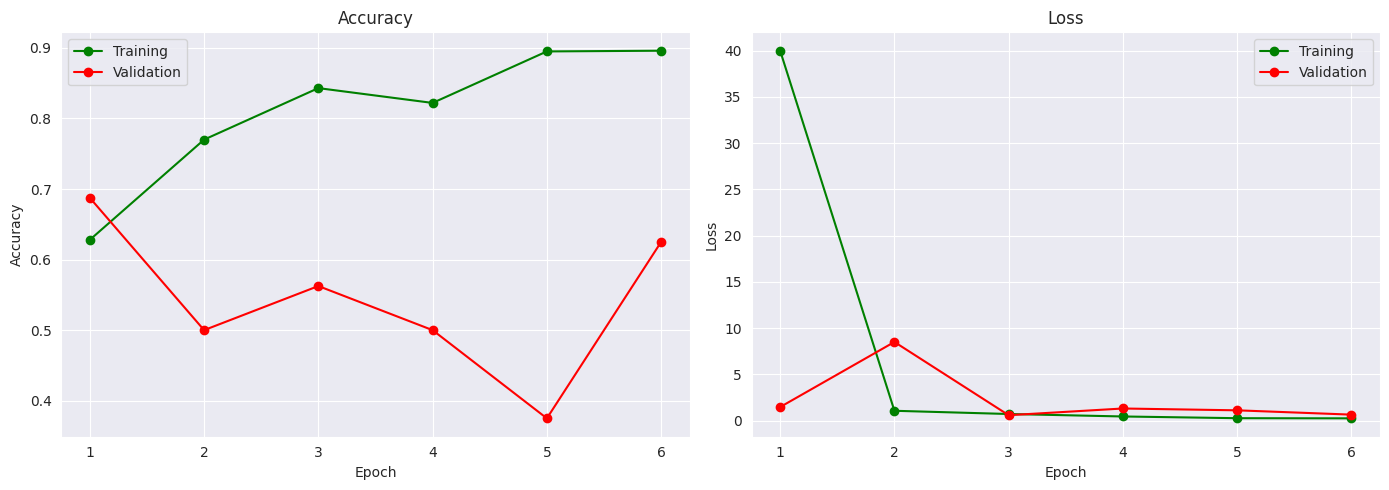

In [ ]:
epochs = list[int](range(1, NUM_EPOCHS + 1))
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(epochs, history['accuracy'], 'go-', label='Training')
ax[0].plot(epochs, history['val_accuracy'], 'ro-', label='Validation')
ax[0].set_title('Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].legend()

ax[1].plot(epochs, history['loss'], 'g-o', label='Training')
ax[1].plot(epochs, history['val_loss'], 'r-o', label='Validation')
ax[1].set_title('Loss')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend()

plt.tight_layout()
plt.show()


> **Checkpoint:** Compare results between training and validation set, is the model overfitting or underfitting? What are some of the options to imrpve the results?

> **Task**  
> Change one thing, retrain the model and compare the results.  
> - NUM_EPOCHS  
> - BATCH_SIZE (16 vs 32)  
> - Uncomment one Dropout layer  
> - Add/remove an augmentation transform  


> **Challenge**  
> Handle imbalance + size-robust classifier  
> **Problem**: Train set is imbalanced (~3:1 pneumonia:normal), and IMG_SIZE is coupled to Linear(256 * 4 * 4, 128). 
> How would you approach these issues? 

When you are happy with the weight or want to preserve it for next time, you can save the model as below.

In [ ]:
# Path to save the trained model
save_dir = f"/ocean/projects/tra210016p/{os.environ.get('USER', 'your_username')}"
os.makedirs(save_dir, exist_ok=True)
model_path = os.path.join(save_dir, 'pneumonia_cnn.pt')

# Save the model
torch.save(model.state_dict(), model_path)
print(f"Model saved to {model_path}")

---
## Block 5 — Evaluate & wrap-up

Test the model, report per-class metrics, and inspect prediction errors.




> **Task**  
> 1. Add the line to run_epoch() on test dataset. 
> How are parameters passed to the function different compared to training above?

In [ ]:
#TODO 
# Add the line to run_epoch() on test dataset. 

test_loss, test_acc = run_epoch(model, test_loader, criterion)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_acc * 100:.2f}%')


Test loss: 0.3894
Test accuracy: 84.13%


Below function has a similar structure to `run_epoch()`, only it prepares the preditction results for down stream analysis, which will create the evaluation report, confusion matrix and image examples. 

In [ ]:
model.eval()
all_preds = []
all_labels = []
all_images = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = (torch.sigmoid(outputs) >= 0.5).long().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy().astype(int))
        all_images.append(images.cpu().numpy())

predictions = np.array(all_preds)
y_true = np.array(all_labels)
test_images = np.concatenate(all_images, axis=0)

print(classification_report(
    y_true, predictions,
    target_names=['Pneumonia (Class 0)', 'Normal (Class 1)'],
))


                     precision    recall  f1-score   support

Pneumonia (Class 0)       0.88      0.87      0.87       390
   Normal (Class 1)       0.78      0.80      0.79       234

           accuracy                           0.84       624
          macro avg       0.83      0.83      0.83       624
       weighted avg       0.84      0.84      0.84       624



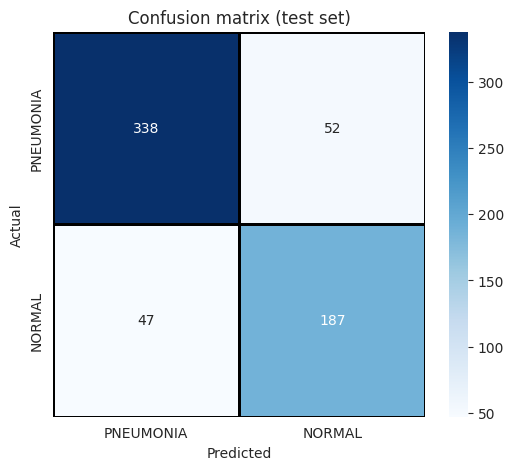

In [20]:
cm = confusion_matrix(y_true, predictions)
cm_df = pd.DataFrame(cm, index=LABELS, columns=LABELS)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, cmap='Blues', annot=True, fmt='d', linewidths=1, linecolor='black')
plt.title('Confusion matrix (test set)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


> **Checkpoint**: Is the model giving more FP (false positives) or FN (false negatives)? Which one is more costly?

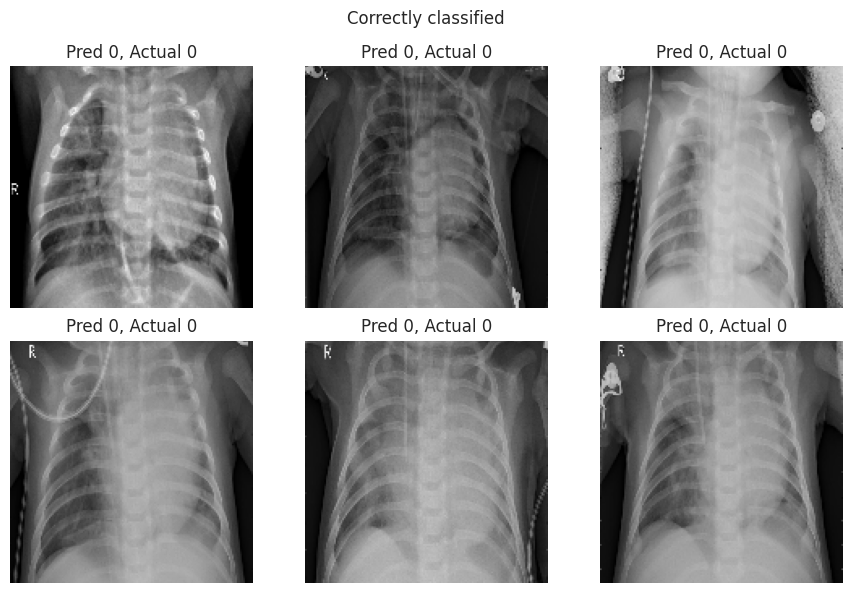

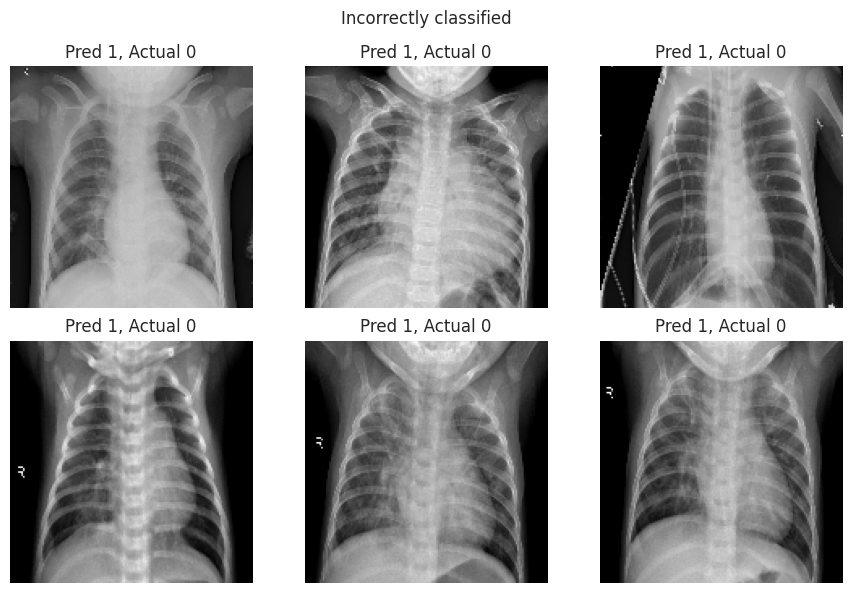

In [ ]:
def plot_examples(indices, title):
    n = min(6, len(indices))
    if n == 0:
        print(f'No examples for: {title}')
        return
    fig, axes = plt.subplots(2, 3, figsize=(9, 6))
    fig.suptitle(title)
    for ax, idx in zip(axes.flat, indices[:n]):
        ax.imshow(test_images[idx].squeeze(), cmap='gray')
        ax.set_title(f'Pred {predictions[idx]}, Actual {int(y_true[idx])}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()


correct = np.where(predictions == y_true)[0]
incorrect = np.where(predictions != y_true)[0]

plot_examples(correct, 'Correctly classified')
plot_examples(incorrect, 'Incorrectly classified')


## Summary

1. Define problem and metric first.
2. Start with a clear baseline.
3. Respect train / val / test splits.
4. Monitor train vs val gap for overfitting.
5. Report test metrics and show failure cases.

## ML Workflow

| Step | This notebook |
|------|---------------|
| **Define problem** | Binary classification: pneumonia vs normal on chest X-ray |
| **Choose metric** | Accuracy, precision/recall per class (false negatives may be clinically costly) |
| **Prepare data** | Load JPEGs, resize, normalize, augment, batch with `DataLoader` |
| **Choose model** | CNN (`PneumoniaCNN`) — images need spatial feature learning |
| **Train** | Minimize `BCEWithLogitsLoss` with `RMSprop` over epochs |
| **Validate** | Monitor val loss/accuracy each epoch; scheduler adjusts learning rate |
| **Test** | Final metrics on held-out test set — **once**, at the end |
| **Report** | Plots, confusion matrix, inspect misclassified images |


> **Closing:** Is there any other data propressing can be done to further improve the performance?  
